Andrew Doherty Munro
DATA 30195
Final Project Notebook

$\textbf{Research Question and Motivation}$

I love being outside, and one thing I love about Chicago is its great parks - one of my favorite things to do in Hyde Park is to spend time at the Point and sit by the water. This project is meant to investigate park access in Chicago, as greenspace is great for exercise, mental health, heat reduction (through canopy coverage), etc. Therefore, I want to ask what demographic factors play into park access in the Chicago area? Do the expansion of parks displace people (mainly low income), either through pricing them out or displacing them with higher income people moving there?

$\textbf{Background and Literature Review}$

forthcoming

$\textbf{Data Sources}$

My main datasource is from the Trust for Public Land (TPL), which has a project called "10 Minute Walk Impact." The shapefiles used in this project can be access here: https://www.tpl.org/park-data-downloads

An unfortunate aspect of TPL's data is that they don't archive past files on their website, so I cannot use their data to see the changing area/coverage of parks. I am going to attempt to solve this by using the Multi-Resolution Land Characteristics Consortium Data, which includes its Land Cover Change: https://www.mrlc.gov/data

This will allow me to see year-over-year changes in land coverage in the Chicago area. I've never worked with Raster Data before, so I may have to pivot if I can't get reasonable traction with it.

Finally, I plan on using Census and ACS Data, specifically making use of MIGPUMAs. Chicago has 19 PUMAs, which should be enough for the purposes of this project to compare year-over-year. The ultimate goal is to see what sort of characteristics of movers precede and follow the expansion of park space.

$\textbf{Initial Results and Data Exploration}$

To begin, I want to explore the nature and characteristics of Chicago's Parks. For now, I am using Cook County as the definition of "Chicago," as the data from the Trust for Public Land includes counties and metropolitan areas,and I don't think clipping to just city limits would be informative. The metro area is quite large and ranges as far as Indiana, which I consider a stretch to call "Chicago."

In [207]:
!pip install stargazer

In [208]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from census import Census
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer

#ignore runtime errors to avoid cluttering output (they don't affect anything)
warnings.filterwarnings("ignore", category=RuntimeWarning)

#fetch Census API key
census_key = os.environ.get("CENSUS_API_KEY")
if not census_key:
    print('Something went wrong with Census Key fetching')

Load in generic "Parks" shapefile, subset to Chicago and project to Illinois State Plane East CRS:

In [57]:
parks = gpd.read_file(r'data/shapefiles/Parks.shp')

chicago_parks = parks[(parks['Park_State'] == 'Illinois') & (parks['Park_Count'] == 'Cook County')]
chicago_parks = chicago_parks.to_crs(epsg=26971)

Plot to get a sense of coverage:

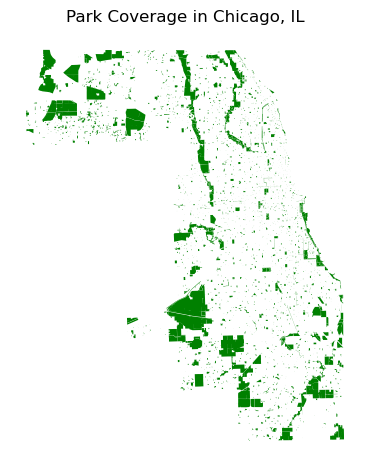

In [58]:
fig, ax = plt.subplots(1, 1)

chicago_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Park Coverage in Chicago, IL')

plt.tight_layout()
plt.show()

Land Trust also Includes a shapefile with helpful statistics attached to each park. However, it doesn't include counties! So a spatial join with the previous shapefile is necessary to get all the info at the county level:

In [59]:
park_stats = gpd.read_file(r'data/shapefiles/Parks_Statistics.shp')
park_stats = park_stats.to_crs(chicago_parks.crs)

#strip out duplicate columns for merging
cols_to_keep = []

for col in park_stats.columns.to_list():
    if col not in chicago_parks.columns.to_list():
        cols_to_keep.append(col)
    elif col == 'geometry':
        cols_to_keep.append(col)

park_stats = park_stats[cols_to_keep]

chicago_parks_full = chicago_parks.sjoin(park_stats,
                                how='left',
                                predicate='intersects')

chicago_parks_full.head()

,ParkID,GISTrkrID,SourceID,Park_Name,Park_Desig,Park_Owner,Park_Local,Park_Manag,Park_Loc_1,Park_Acces,...,SUM_TOTHHS,SUM_WHITE_,SUM_BLACK_,SUM_AMERIN,SUM_ASIAN_,SUM_PACIFI,SUM_OTHRAC,SUM_RACE2U,SUM_HISP_S,Park_Pla_1
34264,1701010-0001,3692,1,Laramie Park,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,477.0,842.0,119.0,3.0,41.0,1.0,2.0,28.0,339.0,1701010
34265,1701010-0002,3692,2,Kiwanis Park,LP,MUNI,VILLAGE OF ALSIP,MUNI,VILLAGE OF ALSIP,3,...,464.0,763.0,114.0,3.0,37.0,1.0,1.0,24.0,312.0,1701010
34266,1701010-0003,3692,3,Freedom Park,LP,SPECIAL_DISTRICT,METRO WATER RECLM DIST,SPECIAL_DISTRICT,METRO WATER RECLM DIST,3,...,486.0,560.0,224.0,1.0,30.0,0.0,1.0,26.0,313.0,1701010
34267,1701010-0004,3692,4,Ketelaar Tot Lot,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,189.0,162.0,130.0,0.0,12.0,0.0,3.0,13.0,204.0,1701010
34268,1701010-0005,3692,5,Lacrosse Tot Lot,LP,SPECIAL_DISTRICT,ALSIP PARK DIST,SPECIAL_DISTRICT,ALSIP PARK DIST,3,...,191.0,227.0,44.0,1.0,11.0,0.0,0.0,7.0,99.0,1701010


How many parks are there in Cook County?

In [60]:
print('There are', len(chicago_parks_full), 'parks in Cook County')

There are 3176 parks in Cook County


There is an "Area" column, but it's not clear what the units are, which warrants investigation:

In [61]:
#Illinois State Plane East uses meters for area, so take that and convert to acres:
chicago_parks_full['area_sqm'] = chicago_parks_full.geometry.area
chicago_parks_full['area_acres'] = chicago_parks_full.geometry.area * 0.000247105

chicago_parks_full[['area_sqm', 'area_acres', 'Park_Size_']].head()

,area_sqm,area_acres,Park_Size_
34264,9738.849271,2.406518,2.406503
34265,6745.211133,1.666775,1.666764
34266,10157.568842,2.509986,2.509964
34267,2182.226756,0.539239,0.539231
34268,727.544414,0.179780,0.179778


It looks like "Park_Size_" measures acres! Now we can ask where/what the biggest parks are. There are a lot of parks (over 3,100!), so a reasonable sample is the top 5%, or about 150 parks.

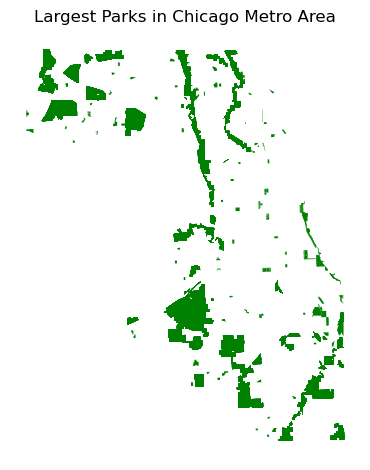

In [62]:
top_5p = np.quantile(chicago_parks_full['Park_Size_'], q=0.95)

biggest_parks = chicago_parks_full[chicago_parks_full['Park_Size_'] >= top_5p]

fig, ax = plt.subplots(1, 1)

biggest_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Largest Parks in Chicago Metro Area')

plt.tight_layout()
plt.show()

Some of these are quite large, but others aren't as massive, and they're pretty spread out so there's good variation. Who has access to these parks? Can start by using the included income statistics, which TPL includes. All statistics are represented by people who live within a 10-minute walk to a given park, which serves as a proxy of access.

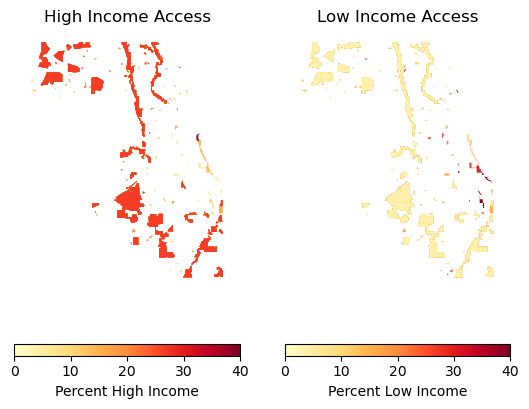

In [63]:
chicago_parks_full['pct_high_inc'] = 100* chicago_parks_full['SUM_HHIHIG'] / chicago_parks_full['SUM_TOTPOP']
chicago_parks_full['pct_low_inc'] = 100 * chicago_parks_full['SUM_HHILOW'] / chicago_parks_full['SUM_TOTPOP']

#refilter to biggest parks so that it includes new columns
biggest_parks = chicago_parks_full[chicago_parks_full['Park_Size_'] >= top_5p]

fig, (ax1, ax2) = plt.subplots(1, 2)

biggest_parks.plot(
    column='pct_high_inc',
    ax=ax1,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Percent High Income',
                 'orientation': 'horizontal'},
    vmin=0,
    vmax=40
)

biggest_parks.plot(
    column='pct_low_inc',
    ax=ax2,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Percent Low Income',
                 'orientation': 'horizontal'},
    vmin=0,
    vmax=40
)

ax1.set_title('High Income Access')
ax2.set_title('Low Income Access')
ax1.set_axis_off()
ax2.set_axis_off()

plt.show()

There's a huge discrepancy! Taking the largest parks, it seems like high income people (as measured by being >125% of median income) are much more likely to be near parks.

Another interesting thing that TPL tracks is in a separate .csv, called "canopy pct". This measures what percentage of the area of a park is canopy, or covered by trees.

In [64]:
add_stats = pd.read_csv('data/shapefiles/AdditionalData.csv')

chicago_parks_full = chicago_parks_full.merge(add_stats, on='ParkID', how='left')

There's a pretty significant outlier:

In [65]:
chicago_parks_full['canopy_pct'].max()

np.float64(249.27074255109775)

Which is likely just measurement error, but worth investigating. This code will look at all parks where "canopy percent" is greater than 100:

In [72]:
print(chicago_parks_full[chicago_parks_full['canopy_pct'] > 100][['Park_Size_', 'canopy_pct']])

      Park_Size_  canopy_pct
2944    0.033552  101.811237
3108    0.001142  249.270743


These parks are super super small (the park with a percent canopy coverage of 249% is only 0.001 acres!) so this is likely just measurement error and these parks can be omitted going forward.

In [73]:
chicago_parks_full = chicago_parks_full[chicago_parks_full['canopy_pct'] <= 100]

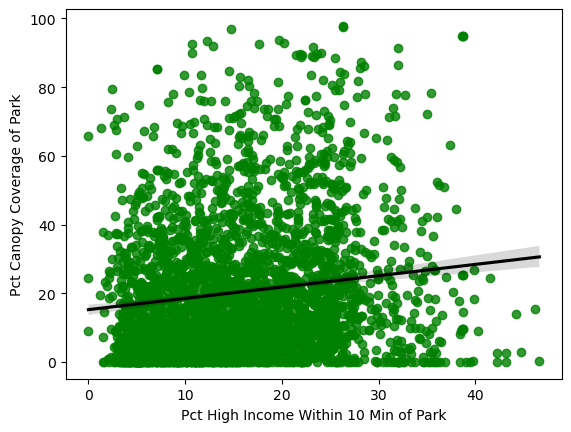

In [74]:
fig, ax = plt.subplots(1, 1)

sns.regplot(data = chicago_parks_full,
            x='pct_high_inc',
            y='canopy_pct',
            color='green',
            line_kws={'color': 'black'}
            )

ax.set_xlabel('Pct High Income Within 10 Min of Park')
ax.set_ylabel('Pct Canopy Coverage of Park')

plt.show()

It seems like there's something there! but the data is very messy given how many parks we have.

$\textbf{Are Parks Related to Housing Prices}$

Now to investigate housing prices and parks in Chicago. The Census includes Median Housing Price as part of its ACS 5-year estimates, with the most granular unit of analysis being the block level. Given how large cook county is, and the fact that block groups tend to be at most a few thousand people, I opt to use tracts instead given that they will have better data due to larger sample size of respondents.

Start by pulling in Census data as usual:

In [151]:
year = 2024

if census_key == "":
    raise ValueError("You need to provide a Census API key to run this code. You can get one for free at https://api.census.gov/data/key_signup.html")

census = Census(key=census_key, year=year)

VARIABLES = {
    "NAME": "name",
    "B25077_001E": "median_home_value",
    "B25064_001E": "median_gross_rent",
    "B01003_001E": "total_population",
    "B01002_001E": "median_age",
    "B03002_003E": "pop_non_hispanic_white",
    "B03002_004E": "pop_black",
    "B03002_006E": "pop_asian",
    "B03002_012E": "pop_hispanic",
    "B19013_001E": "median_household_income",
}

try:
    data = census.acs5.get(
        tuple(VARIABLES.keys()),
        geo={
            "for": "tract:*",
            "in": "state:17 county:031"
        }
    )

except Exception as e:
    print(f"Request failed: {e}")

census_data = pd.DataFrame(data)

In [ ]:
for column in ['state', 'county', 'tract']:
    census_data[column] = census_data[column].astype(str)

census_data['GEOID'] = census_data['state'] + census_data['county'] + census_data['tract']

census_data = census_data.rename(columns=VARIABLES)
census_data = census_data.drop('name', axis=1)

races = ['non_hispanic_white', 'black', 'asian', 'hispanic']

for race in races:
    key = 'pop_' + race
    col = 'pct_' + race

    census_data[col] = census_data[key] / census_data['total_population']

census_data.head()

,median_home_value,median_gross_rent,total_population,median_age,pop_non_hispanic_white,pop_black,pop_asian,pop_hispanic,median_household_income,state,county,tract,GEOID,pct_non_hispanic_white,pct_black,pct_asian,pct_hispanic
0,340700.0,1168.0,4198.0,45.9,1638.0,1632.0,140.0,645.0,74145.0,17,031,010100,17031010100,0.390186,0.388757,0.033349,0.153645
1,239900.0,1378.0,7361.0,32.9,1287.0,2147.0,354.0,3137.0,63056.0,17,031,010201,17031010201,0.174840,0.291672,0.048091,0.426165
2,338000.0,1323.0,2482.0,46.3,863.0,664.0,221.0,656.0,53220.0,17,031,010202,17031010202,0.347703,0.267526,0.089041,0.264303
3,248500.0,1431.0,6477.0,49.3,3091.0,1107.0,488.0,1588.0,73105.0,17,031,010300,17031010300,0.477227,0.170912,0.075344,0.245175
4,231100.0,1347.0,4545.0,29.2,3338.0,254.0,500.0,255.0,54083.0,17,031,010400,17031010400,0.734433,0.055886,0.110011,0.056106


Merge in Census Tract TIGER File:

count    1.332000e+03
mean    -1.092433e+07
std      8.501040e+07
min     -6.666667e+08
25%      5.686825e+04
50%      7.889350e+04
75%      1.079632e+05
max      2.500010e+05
Name: median_household_income, dtype: float64

In [164]:
tracts = gpd.read_file(r'data/shapefiles/Census Tracts/tl_2024_17_tract.shp')

housing_gdf = tracts.merge(census_data,
                           how='right',
                           on='GEOID',
                           indicator=True)

assert len(housing_gdf[housing_gdf['_merge'] == 'both']) == len(housing_gdf)

housing_gdf = housing_gdf.drop('_merge', axis=1)

In [165]:
housing_gdf = gpd.GeoDataFrame(housing_gdf, geometry='geometry')
housing_gdf = housing_gdf.to_crs(chicago_parks_full.crs)

#filter out tracts with no population, as we care about places where people actually live:
housing_gdf = housing_gdf[housing_gdf['total_population'] != 0]

To start, I'm going to look at the closest park for a given census tract, which I'll achieve by doing a dissolve operation. I'll then do an operation to calculate how far a given census tract is from its closest park, as measured by its centroid's distance from the dissolved park.

If doing just distance, there are a few significant outliers and many tracts where distance is 0, because they are in a park. To show variable, I'm going to use the log1p() function from the numpy library, which will smoosh the distance down to a readable scale for plotting. The "1p" aspect adds 1 to every value, so that 0s don't return NaN, but rather return 0 (as log(1) = 0)

In [166]:
one_big_park = chicago_parks_full.dissolve()

housing_gdf['park_dist'] = (
    housing_gdf.geometry.centroid
    .distance(one_big_park.geometry.iloc[0])
)

housing_gdf['logged_park_dist'] = np.log1p(housing_gdf['park_dist'])

Can plot to see if there are regional disparities in access:

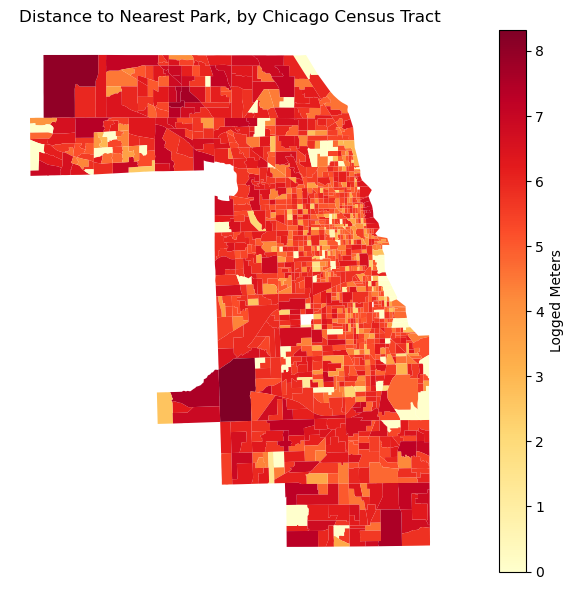

In [167]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

housing_gdf.plot(
    ax=ax,
    column='logged_park_dist',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Logged Meters'}
)

ax.set_axis_off()
ax.set_title('Distance to Nearest Park, by Chicago Census Tract')

plt.tight_layout()
plt.show()

Can also try just omitting the top few outliers:

In [168]:
threshold = housing_gdf['park_dist'].nlargest(5).min()
trimmed_parks = housing_gdf[housing_gdf['park_dist'] < threshold]

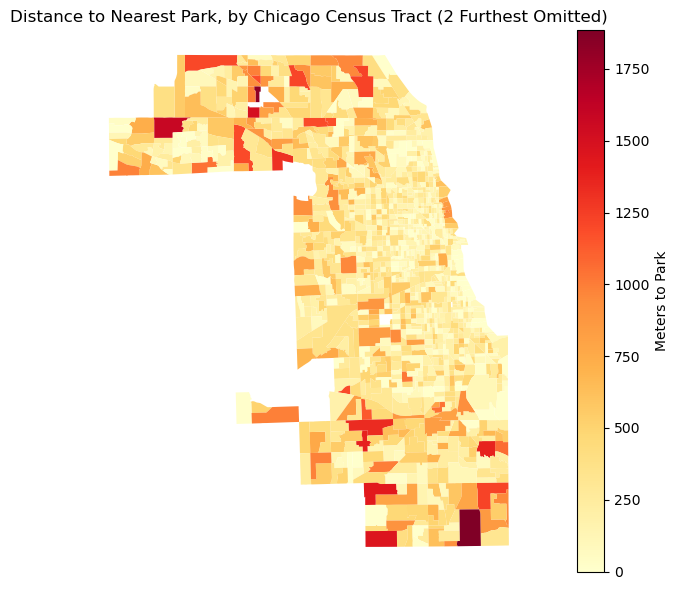

In [169]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

trimmed_parks.plot(
    ax=ax,
    column='park_dist',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Meters to Park'}
)

ax.set_axis_off()
ax.set_title('Distance to Nearest Park, by Chicago Census Tract (2 Furthest Omitted)')

plt.tight_layout()
plt.show()

This does a better job of showing the actual distribution, where most tracts in the downtown area are well-served by parks, while the north and south periphery has pockets with little access. It also preserves the scale, showing that the cetroid of any given tract is not more than 2000 meters from any park, which is pretty good for access.

Now, move onto home value. Omit any tracts where Home Value is coded as missing (which in this case is -666666666), as well as income for good measure, as it will be used later.

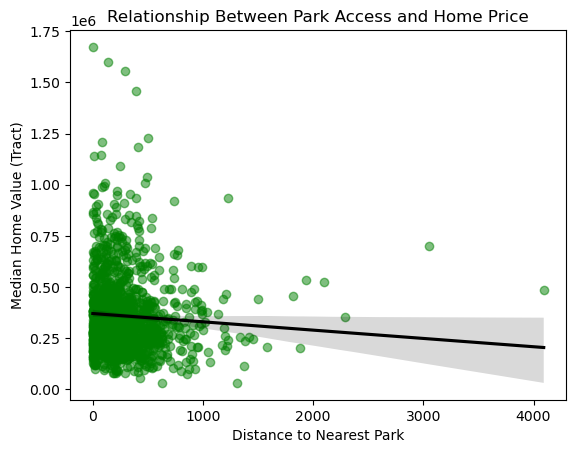

In [211]:
housing_gdf = housing_gdf[(housing_gdf['median_home_value'] > 0) & (housing_gdf['median_household_income'] > 0)]

fig, ax = plt.subplots(1, 1)

sns.regplot(
    ax=ax,
    data = housing_gdf,
    x='park_dist',
    y='median_home_value',
    line_kws={'color': 'black'},
    scatter_kws={'color': 'green', 'alpha': 0.5})

ax.set_xlabel('Distance to Nearest Park')
ax.set_ylabel('Median Home Value (Tract)')
ax.set_title('Relationship Between Park Access and Home Price')

plt.show()

Chicago's largest parks are largely a bigger draw than tiny parks, so one way to investigate further is doing the same analysis on just the largest parks as before. This should also get more variation, as tracts will be more removed from the largest parks!

In [171]:
largest_parks = biggest_parks.dissolve()

housing_gdf['large_park_dist'] = (
    housing_gdf.geometry.centroid
    .distance(largest_parks.geometry.iloc[0])
)

c:\Users\andre\miniconda3\envs\DAP\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


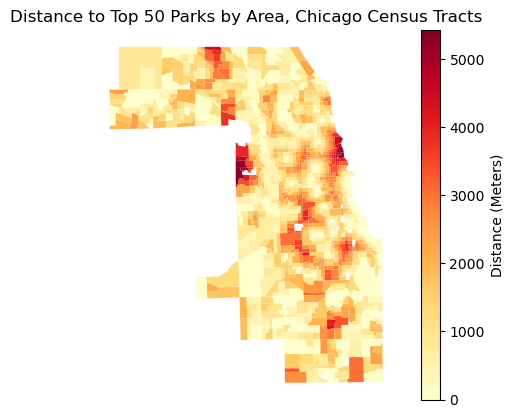

In [172]:
fig, ax = plt.subplots(1, 1)

housing_gdf.plot(
    ax=ax,
    column='large_park_dist',
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Distance (Meters)'}
)

ax.set_axis_off()
ax.set_title('Distance to Top 50 Parks by Area, Chicago Census Tracts')

plt.show()

<Axes: xlabel='large_park_dist', ylabel='median_home_value'>

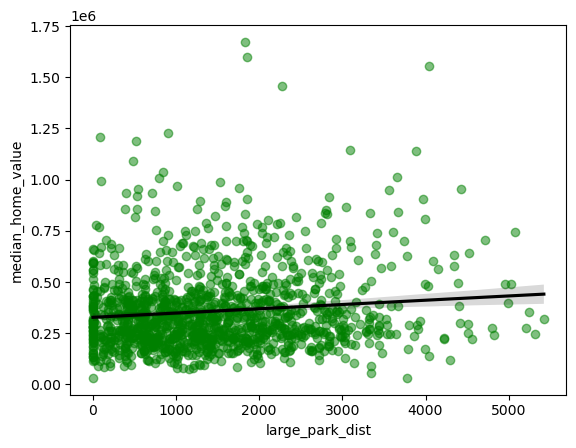

In [173]:
sns.regplot(
    data=housing_gdf,
    x='large_park_dist',
    y='median_home_value',
    line_kws={'color': 'black'},
    scatter_kws={'color': 'green', 'alpha': 0.5}
)

The pattern reverse! It seems that being further from a large park is associated with higher home values. Of course, running a naive regression like this with no controls doesn't tell us much.

One way to visualize a relationship after controlling for other factors is a residualized plot, where you regress your explanatory variables on your controls, and then plot the residuals from this regression on the x axis with your independent variable on the y-axis. 

In [212]:
housing_gdf = housing_gdf[housing_gdf['median_home_value'] > 0]

controls = ["median_age", 
            "pct_non_hispanic_white", 
            "pct_black", 
            "pct_hispanic", 
            "median_household_income"]

all_formula = 'median_home_value ~ park_dist + ' + ' + '.join(controls)

all_parks_model = smf.ols(
    all_formula,
    data=housing_gdf
).fit()

all_x_resid = smf.ols('park_dist ~ ' + ' + '.join(controls), data=housing_gdf).fit().resid
y_resid = smf.ols('median_home_value ~ ' + ' + '.join(controls), data=housing_gdf).fit().resid

all_parks_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      median_home_value   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     368.6
Date:                Mon, 25 May 2026   Prob (F-statistic):          8.63e-275
Time:                        23:36:26   Log-Likelihood:                -16868.
No. Observations:                1288   AIC:                         3.375e+04
Df Residuals:                    1281   BIC:                         3.379e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3.161e+05   3.71e+04      8.511      0.000    2.43e+05    3.89e+05
park_dist                 -70.4420     11.290     -6.239      0.000     -92.591     -48.293
median_age              -3469.9896    529.208     -6.557      0.000   -4508.199   -2431.780
pct_non_hispanic_white   1.456e+04   3.87e+04      0.376      0.707   -6.14e+04    9.05e+04
pct_black               -1.116e+05    3.3e+04     -3.386      0.001   -1.76e+05    -4.7e+04
pct_hispanic            -1.338e+05   3.34e+04     -4.010      0.000   -1.99e+05   -6.84e+04
median_household_income     2.8731      0.108     26.556      0.000       2.661       3.085
==============================================================================
Omnibus:                      412.258   Durbin-Watson:                   1.237
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1870.047
Skew:                           1.446   Prob(JB):                         0.00
Kurtosis:                       8.147   Cond. No.                     1.99e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.99e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [213]:
biggest_formula = 'median_home_value ~ large_park_dist + ' + ' + '.join(controls)

biggest_model = smf.ols(
    biggest_formula,
    data=housing_gdf
).fit()

#y residuals will be the same, as only our independent variable has changed:
big_x_resid = smf.ols('large_park_dist ~ ' + ' + '.join(controls), data=housing_gdf).fit().resid


In [214]:
Stargazer([all_parks_model, biggest_model])

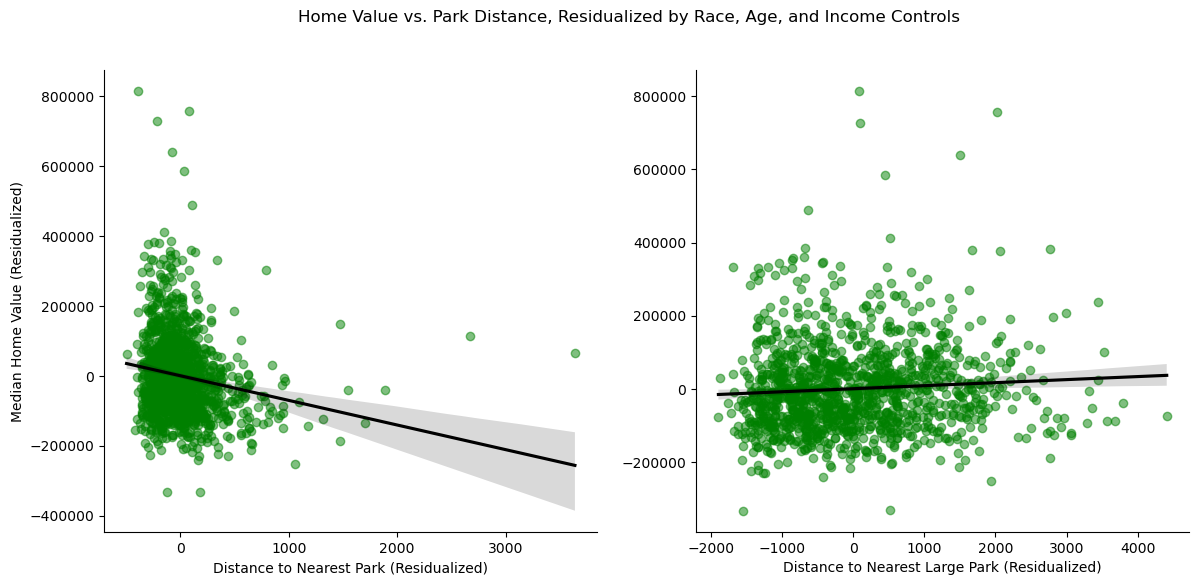

In [215]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(
    ax=ax1,
    x=all_x_resid,
    y=y_resid,
    line_kws={'color': 'black'},
    scatter_kws={'color': 'green', 'alpha': 0.5}
)

sns.regplot(
    ax=ax2,
    x=big_x_resid,
    y=y_resid,
    line_kws={'color': 'black'},
    scatter_kws={'color': 'green', 'alpha': 0.5}
)

sns.despine()

ax1.set_ylabel('Median Home Value (Residualized)')
ax1.set_xlabel('Distance to Nearest Park (Residualized)')
ax2.set_xlabel('Distance to Nearest Large Park (Residualized)')

fig.suptitle('Home Value vs. Park Distance, Residualized by Race, Age, and Income Controls')

plt.show()

Even after controlling for our covariates of race, age, and income, the relationship persists! And as the regressions show, these are highly significant relationships - both have t-values of more than 3 (with associated p-values less that 0.001).

Finally, it would be useful to investigate park characteristics that are more granular than just distance. To do this, I'll match each tract to its nearest park to investigate whether proximity as well as certain park characteristics are signficant.

In [216]:
chicago_parks_full = chicago_parks_full.drop('index_right', axis=1)

housing_gdf_parks = housing_gdf.sjoin_nearest(chicago_parks_full)

KeyError: "['index_right'] not found in axis"

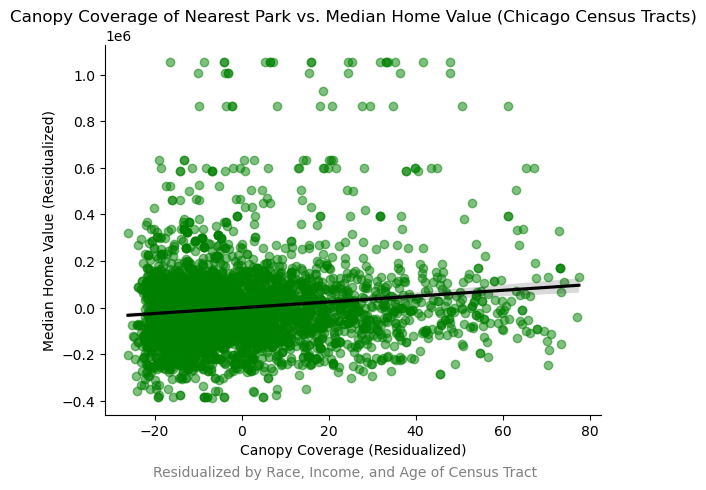

In [218]:
canopy_resids = smf.ols('canopy_pct ~ park_dist + ' + ' + '.join(controls), data=housing_gdf_parks).fit().resid
price_resids = smf.ols('median_home_value ~ park_dist + ' + ' + '.join(controls), data=housing_gdf_parks).fit().resid

fig, ax = plt.subplots(1, 1)

sns.regplot(
    ax=ax,
    x=canopy_resids,
    y=price_resids,
    line_kws={'color': 'black'},
    scatter_kws={'color':'green', 'alpha': 0.5}
)

sns.despine()

ax.set_xlabel('Canopy Coverage (Residualized)')
ax.set_ylabel('Median Home Value (Residualized)')

ax.set_title('Canopy Coverage of Nearest Park vs. Median Home Value (Chicago Census Tracts)', fontsize=12)
fig.text(0.5, -0.02, 'Residualized by Race, Income, and Age of Census Tract', ha='center', fontsize=10, color='gray')

plt.show()
